# IDS 705 — Predicting Recessions Using Global Macroeconomic Indicators
**Models:** Logistic Regression · Random Forest · XGBoost  
**Feature sets:** A (GDP only) · B (core macro) · C (all features)  
**Split:** Time-based — Train ≤2014 | Val 2015–2018 | Test 2019–2022

In [1]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    brier_score_loss,
    confusion_matrix,
    log_loss,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

---
## 1. Load Data

In [2]:
world_bank = pd.read_parquet("../data/Merged/final_merged_panel.parquet")
print(world_bank.shape)
world_bank.head()

(12715, 33)


,country,year,wb_current_account_pct_gdp,wb_exports_pct_gdp,wb_gdp_growth,wb_gov_consumption_pct_gdp,wb_imports_pct_gdp,wb_inflation_cpi,imf_inflation_imf,non_null_feature_count,...,imf_inflation_imf_lag1,imf_inflation_imf_lag2,wb_current_account_pct_gdp_chg1,wb_exports_pct_gdp_chg1,wb_gdp_growth_chg1,wb_gov_consumption_pct_gdp_chg1,wb_imports_pct_gdp_chg1,wb_inflation_cpi_chg1,imf_inflation_imf_chg1,recession
0,Afghanistan,2002,-2.35799,10.420817,28.600001,22.109219,36.289077,12.686269,37.07650,2,...,37.07650,37.07650,0.0,0.0,-19.767723,0.0,0.0,0.000000,-4.50225,0
1,Afghanistan,2003,-2.35799,10.420817,8.832278,22.109219,36.289077,12.686269,32.57425,2,...,37.07650,37.07650,0.0,0.0,-19.767723,0.0,0.0,0.000000,-4.50225,0
2,Afghanistan,2004,-2.35799,10.420817,1.414118,22.109219,36.289077,12.686269,32.68175,2,...,32.57425,37.07650,0.0,0.0,-7.418160,0.0,0.0,0.000000,0.10750,0
3,Afghanistan,2005,-2.35799,10.420817,11.229715,22.109219,36.289077,12.686269,33.22900,3,...,32.68175,32.57425,0.0,0.0,9.815597,0.0,0.0,0.000000,0.54725,0
4,Afghanistan,2006,-2.35799,10.420817,5.357403,22.109219,36.289077,6.784597,32.25250,3,...,33.22900,32.68175,0.0,0.0,-5.872312,0.0,0.0,-5.901672,-0.97650,0


---
## 2. Target Construction

`recession_next_year = 1` if real GDP growth in **t+1** is negative for that country, 0 otherwise.  
This is a per-country definition — NOT the global 2008/2009/2020 label. Positive class rate ~15.3%.

In [3]:
world_bank = world_bank.sort_values(["country", "year"]).reset_index(drop=True)

world_bank["recession_next_year"] = (
    world_bank.groupby("country")["wb_gdp_growth"]
    .shift(-1)
    .lt(0)
    .astype(int)
)

world_bank = world_bank.dropna(subset=["recession_next_year"])
world_bank["recession_next_year"] = world_bank["recession_next_year"].astype(
    int)

print(f"Dataset: {world_bank.shape}")
print(f"Positive class rate: {world_bank['recession_next_year'].mean():.1%}")

Dataset: (12715, 34)
Positive class rate: 15.0%


---
## 3. Feature Sets A / B / C

In [4]:
GDP_COLS = [c for c in world_bank.columns if "gdp_growth" in c and c !=
            "recession_next_year"]
CORE_COLS = GDP_COLS + [c for c in world_bank.columns
                        if any(k in c for k in ["inflation", "gov_consumption"])]
ALL_COLS = CORE_COLS + [c for c in world_bank.columns
                        if any(k in c for k in ["trade", "imports", "exports", "current_account"])]

# Deduplicate
CORE_COLS = list(dict.fromkeys(CORE_COLS))
ALL_COLS = list(dict.fromkeys(ALL_COLS))

print(f"A (GDP only):   {len(GDP_COLS)} features")
print(f"B (core macro): {len(CORE_COLS)} features")
print(f"C (all):        {len(ALL_COLS)} features")

A (GDP only):   4 features
B (core macro): 16 features
C (all):        28 features


---
## 4. Time-Based Split

Train ≤2014 · Val 2015–2018 · Test 2019–2022  
Test window includes COVID shock — val→test gap is regime shift, not overfitting.

In [5]:
train_df = world_bank[world_bank["year"] <= 2014]
val_df = world_bank[(world_bank["year"] >= 2015) &
                    (world_bank["year"] <= 2018)]
test_df = world_bank[world_bank["year"] >= 2019]

y_train = train_df["recession_next_year"]
y_val = val_df["recession_next_year"]
y_test = test_df["recession_next_year"]

print(f"Train: {len(train_df):,} obs | recession rate: {y_train.mean():.1%}")
print(f"Val:   {len(val_df):,} obs | recession rate: {y_val.mean():.1%}")
print(
    f"Test:  {len(test_df):,} obs | recession rate: {y_test.mean():.1%}  <- COVID window")

Train: 9,686 obs | recession rate: 15.5%
Val:   983 obs | recession rate: 11.2%
Test:  2,046 obs | recession rate: 14.6%  <- COVID window


---
## 5. Helper Functions

In [6]:
def prepare_features(train_df, val_df, test_df, feature_cols, apply_pca=True, pca_variance=0.95):
    """
    One-hot encode country, scale with StandardScaler, optionally apply PCA.
    All transforms fitted on train only to prevent leakage.
    """
    base_cols = [c for c in feature_cols if c in train_df.columns]

    def get_X(df):
        X = df[base_cols].copy().reset_index(drop=True)
        dummies = pd.get_dummies(df[["country"]], columns=[
                                 "country"], drop_first=True).reset_index(drop=True)
        return pd.concat([X, dummies], axis=1).fillna(0)

    X_tr = get_X(train_df)
    X_v = get_X(val_df).reindex(columns=X_tr.columns, fill_value=0)
    X_te = get_X(test_df).reindex(columns=X_tr.columns, fill_value=0)

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_v_s = scaler.transform(X_v)
    X_te_s = scaler.transform(X_te)

    if apply_pca:
        pca = PCA(n_components=pca_variance, random_state=42)
        X_tr_s = pca.fit_transform(X_tr_s)
        X_v_s = pca.transform(X_v_s)
        X_te_s = pca.transform(X_te_s)
        print(f"  PCA: {X_tr.shape[1]} -> {pca.n_components_} components "
              f"({pca.explained_variance_ratio_.sum():.1%} variance retained)")

    return X_tr_s, X_v_s, X_te_s


def evaluate(model, X, y_true):
    """Primary metrics: probabilistic focus per report."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)
    return {
        "AUC":      round(roc_auc_score(y_true, y_prob), 3),
        "Brier":    round(brier_score_loss(y_true, y_prob), 3),
        "AUPRC":    round(average_precision_score(y_true, y_prob), 3),
        "LogLoss":  round(log_loss(y_true, y_prob), 3),
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
    }


def plot_roc_pr(models_probs, y_true, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for label, y_prob in models_probs.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[0].plot(
            fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_true, y_prob):.3f})")
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        axes[1].plot(
            rec, prec, label=f"{label} (AP={average_precision_score(y_true, y_prob):.3f})")

    axes[0].plot([0, 1], [0, 1], "k--")
    axes[0].set(xlabel="FPR", ylabel="TPR", title=f"ROC — {title}")
    axes[0].legend(fontsize=8)

    axes[1].axhline(y_true.mean(), color="k", linestyle="--",
                    label="Baseline (prevalence)")
    axes[1].set(xlabel="Recall", ylabel="Precision",
                title=f"Precision-Recall — {title}")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# Store all results for Table B1
all_results = []
stored = {}  # store models + transformed X for later plotting
print("Helpers ready.")

Helpers ready.


---
## 6. Logistic Regression (Baseline)

Per report: L1/L2, GridSearchCV, 5-fold stratified CV, ROC-AUC scoring.  
Best from paper: `C=0.1, penalty=L1, solver=liblinear, class_weight=balanced`

In [7]:
logreg_param_grid = {
    "C":            [0.001, 0.01, 0.1, 1.0, 10.0],
    "penalty":      ["l1", "l2"],
    "class_weight": ["balanced", None],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for feat_name, feat_cols in [("A", GDP_COLS), ("B", CORE_COLS), ("C", ALL_COLS)]:
    print(f"\n=== LogReg | Feature Set {feat_name} ===")
    X_tr, X_v, X_te = prepare_features(train_df, val_df, test_df, feat_cols)

    gs = GridSearchCV(
        LogisticRegression(solver="liblinear", max_iter=1000),
        logreg_param_grid, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    gs.fit(X_tr, y_train)
    best = gs.best_estimator_
    print(f"  Best: {gs.best_params_} | CV AUC: {gs.best_score_:.3f}")

    val_m = evaluate(best, X_v, y_val)
    test_m = evaluate(best, X_te, y_test)
    print(
        f"  Val  -> AUC: {val_m['AUC']} | Brier: {val_m['Brier']} | AUPRC: {val_m['AUPRC']}")
    print(
        f"  Test -> AUC: {test_m['AUC']} | Brier: {test_m['Brier']} | AUPRC: {test_m['AUPRC']}")

    key = f"LogReg_{feat_name}"
    stored[key] = {"model": best, "X_val": X_v, "X_test": X_te}
    all_results.append({"Experiment": f"{feat_name}: {'GDP only' if feat_name == 'A' else 'Core macro' if feat_name == 'B' else 'All'}",
                        "Model": "LogReg",
                        "Val AUC": val_m["AUC"], "Val Brier": val_m["Brier"],
                        "Test AUC": test_m["AUC"], "Test Brier": test_m["Brier"],
                        "Test AUPRC": test_m["AUPRC"]})


=== LogReg | Feature Set A ===
  PCA: 251 -> 236 components (95.1% variance retained)
  Best: {'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2'} | CV AUC: 0.734
  Val  -> AUC: 0.803 | Brier: 0.22 | AUPRC: 0.354
  Test -> AUC: 0.683 | Brier: 0.226 | AUPRC: 0.255

=== LogReg | Feature Set B ===
  PCA: 263 -> 240 components (95.1% variance retained)
  Best: {'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2'} | CV AUC: 0.739
  Val  -> AUC: 0.808 | Brier: 0.218 | AUPRC: 0.353
  Test -> AUC: 0.685 | Brier: 0.226 | AUPRC: 0.254

=== LogReg | Feature Set C ===
  PCA: 275 -> 242 components (95.0% variance retained)
  Best: {'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2'} | CV AUC: 0.735
  Val  -> AUC: 0.799 | Brier: 0.223 | AUPRC: 0.322
  Test -> AUC: 0.681 | Brier: 0.23 | AUPRC: 0.248


---
## 7. Random Forest

Per report: 400 trees, max_depth=8, class_weight=balanced.  
RandomizedSearchCV tunes around these anchors.

In [8]:
rf_param_dist = {
    "n_estimators":      [300, 400, 500],
    "max_depth":         [6, 8, 10],
    "max_features":      ["sqrt", 0.5, 0.7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}

for feat_name, feat_cols in [("A", GDP_COLS), ("B", CORE_COLS), ("C", ALL_COLS)]:
    print(f"\n=== RandomForest | Feature Set {feat_name} ===")
    X_tr, X_v, X_te = prepare_features(train_df, val_df, test_df, feat_cols)

    search = RandomizedSearchCV(
        RandomForestClassifier(
            criterion="gini", class_weight="balanced", random_state=42, n_jobs=-1),
        rf_param_dist, n_iter=20, cv=cv, scoring="roc_auc",
        n_jobs=-1, random_state=42, verbose=0
    )
    search.fit(X_tr, y_train)
    best = search.best_estimator_
    print(f"  Best: {search.best_params_} | CV AUC: {search.best_score_:.3f}")

    val_m = evaluate(best, X_v, y_val)
    test_m = evaluate(best, X_te, y_test)
    print(
        f"  Val  -> AUC: {val_m['AUC']} | Brier: {val_m['Brier']} | AUPRC: {val_m['AUPRC']}")
    print(
        f"  Test -> AUC: {test_m['AUC']} | Brier: {test_m['Brier']} | AUPRC: {test_m['AUPRC']}")

    key = f"RF_{feat_name}"
    stored[key] = {"model": best, "X_val": X_v, "X_test": X_te}
    all_results.append({"Experiment": f"{feat_name}: {'GDP only' if feat_name == 'A' else 'Core macro' if feat_name == 'B' else 'All'}",
                        "Model": "RandomForest",
                        "Val AUC": val_m["AUC"], "Val Brier": val_m["Brier"],
                        "Test AUC": test_m["AUC"], "Test Brier": test_m["Brier"],
                        "Test AUPRC": test_m["AUPRC"]})


=== RandomForest | Feature Set A ===
  PCA: 251 -> 236 components (95.1% variance retained)
  Best: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 6} | CV AUC: 0.762
  Val  -> AUC: 0.817 | Brier: 0.158 | AUPRC: 0.306
  Test -> AUC: 0.687 | Brier: 0.189 | AUPRC: 0.248

=== RandomForest | Feature Set B ===
  PCA: 263 -> 240 components (95.1% variance retained)
  Best: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 6} | CV AUC: 0.760
  Val  -> AUC: 0.81 | Brier: 0.155 | AUPRC: 0.328
  Test -> AUC: 0.699 | Brier: 0.183 | AUPRC: 0.265

=== RandomForest | Feature Set C ===
  PCA: 275 -> 242 components (95.0% variance retained)
  Best: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 6} | CV AUC: 0.752
  Val  -> AUC: 0.78 | Brier: 0.171 | AUPRC: 0.288
  Test -> AUC: 0.699 | Brier: 0.185 | AUPRC: 0.255


---
## 8. XGBoost

Per report: 400 trees, depth=4, learning_rate=0.05, scale_pos_weight=inverse class frequency.

In [9]:
neg, pos = np.bincount(y_train)
spw = neg / pos
print(f"scale_pos_weight: {spw:.2f} (neg/pos = {neg}/{pos})")

xgb_param_dist = {
    "n_estimators":     [300, 400, 500],
    "max_depth":        [3, 4, 6],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha":        [0, 0.1, 0.5],
    "reg_lambda":       [0.5, 1.0, 2.0],
}

for feat_name, feat_cols in [("A", GDP_COLS), ("B", CORE_COLS), ("C", ALL_COLS)]:
    print(f"\n=== XGBoost | Feature Set {feat_name} ===")
    X_tr, X_v, X_te = prepare_features(train_df, val_df, test_df, feat_cols)

    search = RandomizedSearchCV(
        XGBClassifier(eval_metric="logloss", scale_pos_weight=spw,
                      random_state=42, n_jobs=-1),
        xgb_param_dist, n_iter=20, cv=cv, scoring="roc_auc",
        n_jobs=-1, random_state=42, verbose=0
    )
    search.fit(X_tr, y_train)
    best = search.best_estimator_
    print(f"  Best: {search.best_params_} | CV AUC: {search.best_score_:.3f}")

    val_m = evaluate(best, X_v, y_val)
    test_m = evaluate(best, X_te, y_test)
    print(
        f"  Val  -> AUC: {val_m['AUC']} | Brier: {val_m['Brier']} | AUPRC: {val_m['AUPRC']}")
    print(
        f"  Test -> AUC: {test_m['AUC']} | Brier: {test_m['Brier']} | AUPRC: {test_m['AUPRC']}")

    key = f"XGB_{feat_name}"
    stored[key] = {"model": best, "X_val": X_v, "X_test": X_te}
    all_results.append({"Experiment": f"{feat_name}: {'GDP only' if feat_name == 'A' else 'Core macro' if feat_name == 'B' else 'All'}",
                        "Model": "XGBoost",
                        "Val AUC": val_m["AUC"], "Val Brier": val_m["Brier"],
                        "Test AUC": test_m["AUC"], "Test Brier": test_m["Brier"],
                        "Test AUPRC": test_m["AUPRC"]})

scale_pos_weight: 5.45 (neg/pos = 8184/1502)

=== XGBoost | Feature Set A ===
  PCA: 251 -> 236 components (95.1% variance retained)
  Best: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8} | CV AUC: 0.764
  Val  -> AUC: 0.817 | Brier: 0.176 | AUPRC: 0.335
  Test -> AUC: 0.688 | Brier: 0.205 | AUPRC: 0.256

=== XGBoost | Feature Set B ===
  PCA: 263 -> 240 components (95.1% variance retained)
  Best: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7} | CV AUC: 0.765
  Val  -> AUC: 0.813 | Brier: 0.175 | AUPRC: 0.348
  Test -> AUC: 0.7 | Brier: 0.201 | AUPRC: 0.264

=== XGBoost | Feature Set C ===
  PCA: 275 -> 242 components (95.0% variance retained)
  Best: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9} | CV AUC: 0.

---
## 9. Table B1 — All 9 Model × Feature Combinations

In [10]:
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index(["Experiment", "Model"])
print("Table B1. Validation (2015-2018) and Test (2019-2022) metrics.")
print("Note: val->test AUC gap reflects COVID regime shift, not overfitting.\n")
results_df

Table B1. Validation (2015-2018) and Test (2019-2022) metrics.
Note: val->test AUC gap reflects COVID regime shift, not overfitting.



,,Val AUC,Val Brier,Test AUC,Test Brier,Test AUPRC
Experiment,Model,,,,,
A: GDP only,LogReg,0.803,0.220,0.683,0.226,0.255
B: Core macro,LogReg,0.808,0.218,0.685,0.226,0.254
C: All,LogReg,0.799,0.223,0.681,0.230,0.248
A: GDP only,RandomForest,0.817,0.158,0.687,0.189,0.248
B: Core macro,RandomForest,0.810,0.155,0.699,0.183,0.265
C: All,RandomForest,0.780,0.171,0.699,0.185,0.255
A: GDP only,XGBoost,0.817,0.176,0.688,0.205,0.256
B: Core macro,XGBoost,0.813,0.175,0.700,0.201,0.264
C: All,XGBoost,0.810,0.182,0.692,0.202,0.248


---
## 10. ROC & Precision-Recall Curves — Test Set, Feature Set C

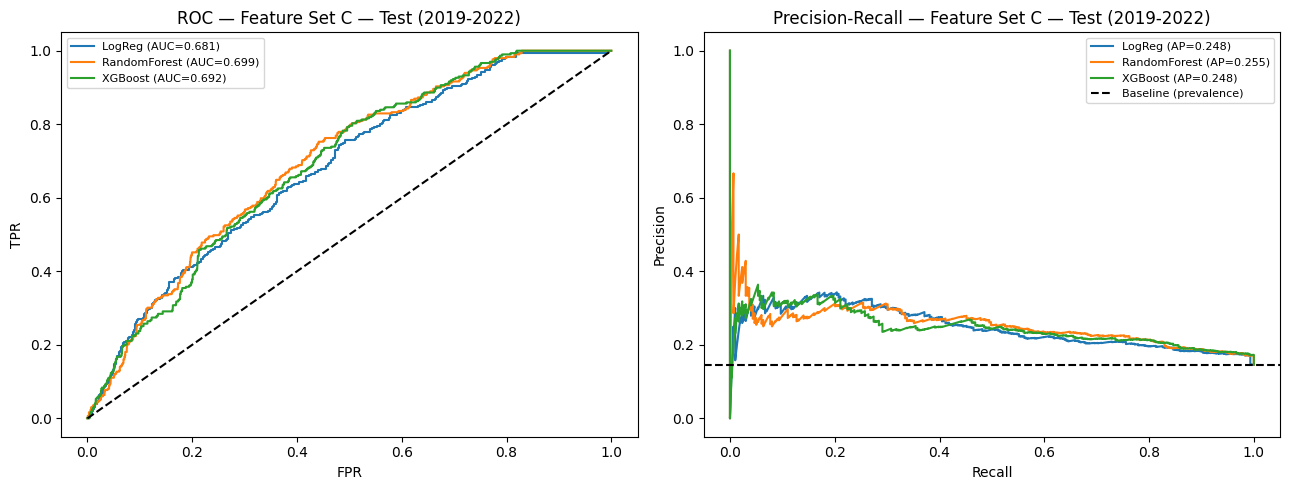

In [11]:
probs_C = {
    "LogReg":       stored["LogReg_C"]["model"].predict_proba(stored["LogReg_C"]["X_test"])[:, 1],
    "RandomForest": stored["RF_C"]["model"].predict_proba(stored["RF_C"]["X_test"])[:, 1],
    "XGBoost":      stored["XGB_C"]["model"].predict_proba(stored["XGB_C"]["X_test"])[:, 1],
}
plot_roc_pr(probs_C, y_test, title="Feature Set C — Test (2019-2022)")

---
## 11. Confusion Matrices at Threshold 0.5

**Sanity check only.** For policy use, threshold should be tuned to the cost of false negatives  
(missed recession = costly) vs false positives (false alarm = less costly but not free).

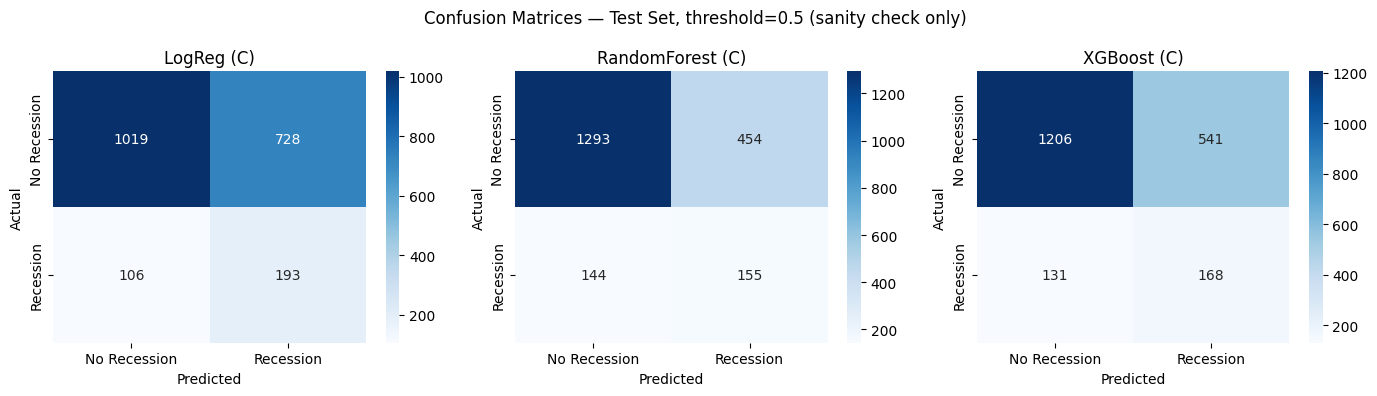

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, key) in zip(axes, [
    ("LogReg (C)",       "LogReg_C"),
    ("RandomForest (C)", "RF_C"),
    ("XGBoost (C)",      "XGB_C"),
]):
    y_pred = stored[key]["model"].predict(stored[key]["X_test"])
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Recession", "Recession"],
                yticklabels=["No Recession", "Recession"])
    ax.set_title(label)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle(
    "Confusion Matrices — Test Set, threshold=0.5 (sanity check only)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 12. Feature Importance — RF & XGBoost (Feature Set C)

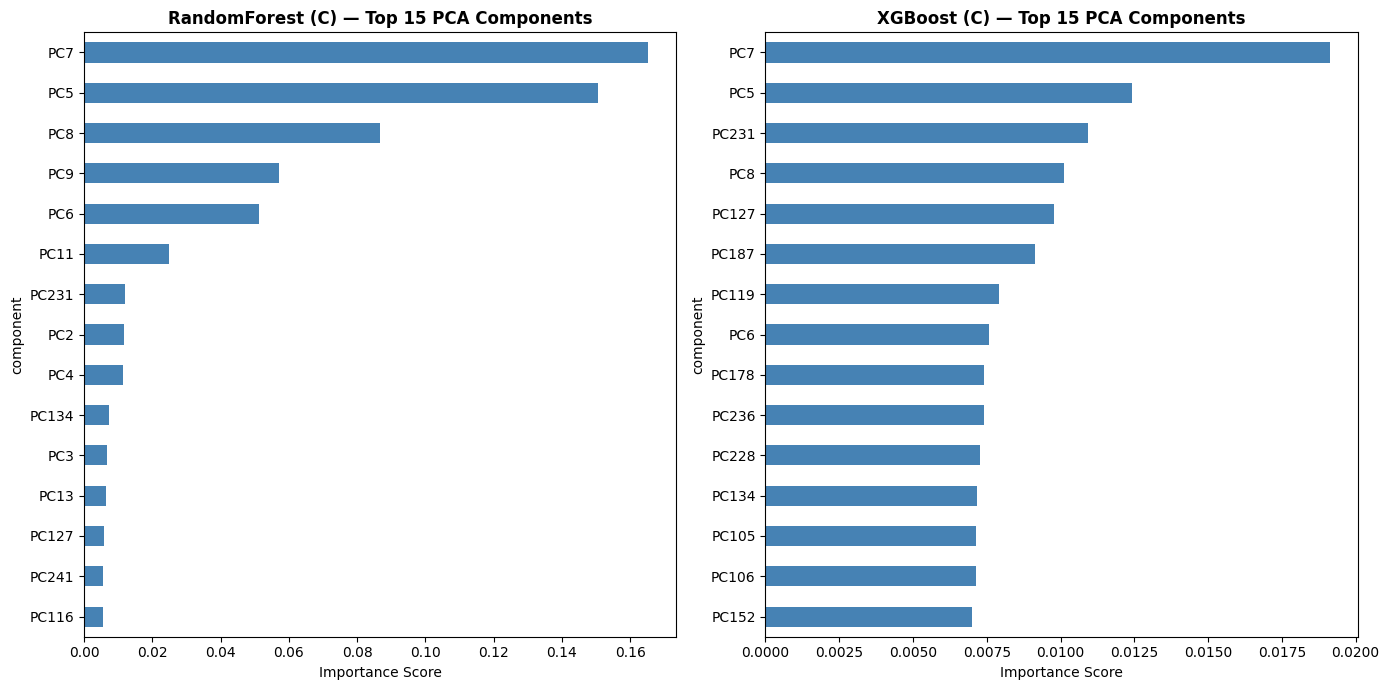

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (label, key) in zip(axes, [("RandomForest (C)", "RF_C"), ("XGBoost (C)", "XGB_C")]):
    n = stored[key]["model"].n_features_in_
    imp_df = (
        pd.DataFrame({
            "component": [f"PC{i+1}" for i in range(n)],
            "importance": stored[key]["model"].feature_importances_
        })
        .sort_values("importance", ascending=False).head(15)
        .sort_values("importance")
    )
    imp_df.plot.barh(x="component", y="importance", ax=ax,
                     color="steelblue", legend=False)
    ax.set_title(f"{label} — Top 15 PCA Components", fontweight="bold")
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

In [14]:
import joblib

for key, d in stored.items():
    joblib.dump(d["model"], f"{key}_model.pkl")
    np.save(f"{key}_X_test.npy", d["X_test"])

np.save("y_test.npy", y_test.values)

## Model Enhancement

1. Start with bootstrapping confidence intervals to make AUC values more clear for stakeholders

In [ ]:
model_keys = {
    "LogReg_A", "LogReg_B", "LogReg_C",
    "RF_A", "RF_B", "RF_C",
    "XGB_A", "XGB_B", "XGB_C",
}

stored = {}
for key in model_keys:
    stored[key] = {
        "model": joblib.load(f"{key}_model.pkl"),
        "X_test": np.load(f"{key}_X_test.npy"),
    }

y_test = pd.Series(np.load("y_test.npy"))

In [ ]:
# Bootstrap confidence intervals for test metrics

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss


def bootstrap_metric_ci(
    y_true, y_prob, metric_fn, n_bootstrap=1000, ci=95, random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    n = len(y_true)

    boot_scores = []

    for _ in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        y_sample = y_true[idx]
        prob_sample = y_prob[idx]

        # skip samples with only one class because AUC/AUPRC break there
        if len(np.unique(y_sample)) < 2:
            continue

        boot_scores.append(metric_fn(y_sample, prob_sample))

    lower = np.percentile(boot_scores, (100 - ci) / 2)
    upper = np.percentile(boot_scores, 100 - (100 - ci) / 2)
    mean = metric_fn(y_true, y_prob)

    return mean, lower, upper


bootstrap_results = []

model_keys = {
    "LogReg A: GDP only": "LogReg_A",
    "LogReg B: Core macro": "LogReg_B",
    "LogReg C: All": "LogReg_C",
    "Random Forest A: GDP only": "RF_A",
    "Random Forest B: Core macro": "RF_B",
    "Random Forest C: All": "RF_C",
    "XGBoost A: GDP only": "XGB_A",
    "XGBoost B: Core macro": "XGB_B",
    "XGBoost C: All": "XGB_C",
}

for model_name, key in model_keys.items():
    y_prob = stored[key]["model"].predict_proba(stored[key]["X_test"])[:, 1]

    auc_mean, auc_low, auc_high = bootstrap_metric_ci(
        y_test, y_prob, roc_auc_score)

    auprc_mean, auprc_low, auprc_high = bootstrap_metric_ci(
        y_test, y_prob, average_precision_score
    )

    brier_mean, brier_low, brier_high = bootstrap_metric_ci(
        y_test, y_prob, brier_score_loss
    )

    bootstrap_results.append(
        {
            "Model": model_name,
            "Test AUC": auc_mean,
            "AUC 95% CI": f"[{auc_low:.3f}, {auc_high:.3f}]",
            "Test AUPRC": auprc_mean,
            "AUPRC 95% CI": f"[{auprc_low:.3f}, {auprc_high:.3f}]",
            "Test Brier": brier_mean,
            "Brier 95% CI": f"[{brier_low:.3f}, {brier_high:.3f}]",
        }
    )

bootstrap_df = pd.DataFrame(bootstrap_results)

bootstrap_df = bootstrap_df.sort_values("Test AUC", ascending=False)

bootstrap_df

,Model,Test AUC,AUC 95% CI,Test AUPRC,AUPRC 95% CI,Test Brier,Brier 95% CI
7,XGBoost B: Core macro,0.700248,"[0.668, 0.729]",0.264351,"[0.227, 0.308]",0.201491,"[0.194, 0.209]"
5,Random Forest C: All,0.699008,"[0.668, 0.727]",0.255437,"[0.219, 0.301]",0.184706,"[0.178, 0.192]"
4,Random Forest B: Core macro,0.698885,"[0.668, 0.728]",0.265224,"[0.227, 0.310]",0.182916,"[0.175, 0.191]"
8,XGBoost C: All,0.691614,"[0.660, 0.721]",0.247943,"[0.213, 0.293]",0.201505,"[0.194, 0.210]"
6,XGBoost A: GDP only,0.688399,"[0.655, 0.718]",0.255952,"[0.216, 0.301]",0.205210,"[0.197, 0.213]"
3,Random Forest A: GDP only,0.686776,"[0.653, 0.716]",0.247572,"[0.212, 0.293]",0.188531,"[0.181, 0.196]"
1,LogReg B: Core macro,0.684759,"[0.654, 0.713]",0.253645,"[0.218, 0.299]",0.225513,"[0.219, 0.232]"
0,LogReg A: GDP only,0.683186,"[0.652, 0.711]",0.254992,"[0.218, 0.300]",0.226346,"[0.220, 0.233]"
2,LogReg C: All,0.681076,"[0.652, 0.710]",0.247867,"[0.213, 0.291]",0.229942,"[0.223, 0.237]"


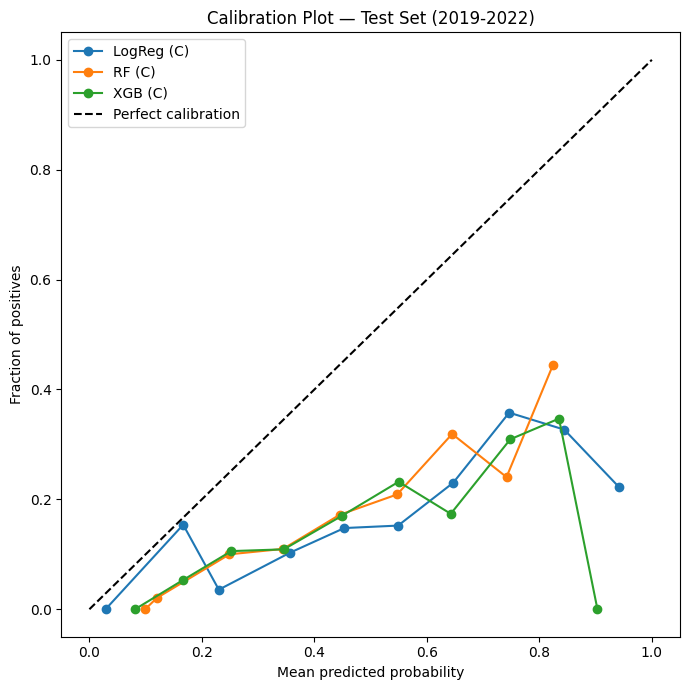

In [16]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

for label, key in [
    ("LogReg (C)", "LogReg_C"),
    ("RF (C)", "RF_C"),
    ("XGB (C)", "XGB_C"),
]:
    y_prob = stored[key]["model"].predict_proba(stored[key]["X_test"])[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=label)

ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Plot — Test Set (2019-2022)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# regenerate validation features for each model
for feat_name, feat_cols in [("A", GDP_COLS), ("B", CORE_COLS), ("C", ALL_COLS)]:
    X_tr, X_v, X_te = prepare_features(train_df, val_df, test_df, feat_cols)

    for prefix in ["LogReg", "RF", "XGB"]:
        key = f"{prefix}_{feat_name}"
        if key in stored:
            stored[key]["X_val"] = X_v

  PCA: 251 -> 236 components (95.1% variance retained)
  PCA: 263 -> 240 components (95.1% variance retained)
  PCA: 275 -> 242 components (95.0% variance retained)


In [23]:
from sklearn.linear_model import LogisticRegression

calibrated_models = {}

for label, key in [
    ("LogReg_C", "LogReg_C"),
    ("RF_C", "RF_C"),
    ("XGB_C", "XGB_C"),
]:
    # Get raw probabilities
    val_probs = stored[key]["model"].predict_proba(stored[key]["X_val"])[:, 1]
    test_probs = stored[key]["model"].predict_proba(
        stored[key]["X_test"])[:, 1]

    # Platt scaling: fit logistic regression on val probabilities
    platt = LogisticRegression()
    platt.fit(val_probs.reshape(-1, 1), y_val)
    y_prob_cal = platt.predict_proba(test_probs.reshape(-1, 1))[:, 1]

    brier_orig = brier_score_loss(y_test, test_probs)
    brier_cal = brier_score_loss(y_test, y_prob_cal)
    auc_orig = roc_auc_score(y_test, test_probs)
    auc_cal = roc_auc_score(y_test, y_prob_cal)

    calibrated_models[f"{key}_platt"] = {"y_prob": y_prob_cal}
    print(f"{label}: Brier {brier_orig:.4f} -> {brier_cal:.4f} | AUC {auc_orig:.3f} -> {auc_cal:.3f}")

LogReg_C: Brier 0.2299 -> 0.1204 | AUC 0.681 -> 0.681
RF_C: Brier 0.1847 -> 0.1192 | AUC 0.699 -> 0.699
XGB_C: Brier 0.2015 -> 0.1200 | AUC 0.692 -> 0.692


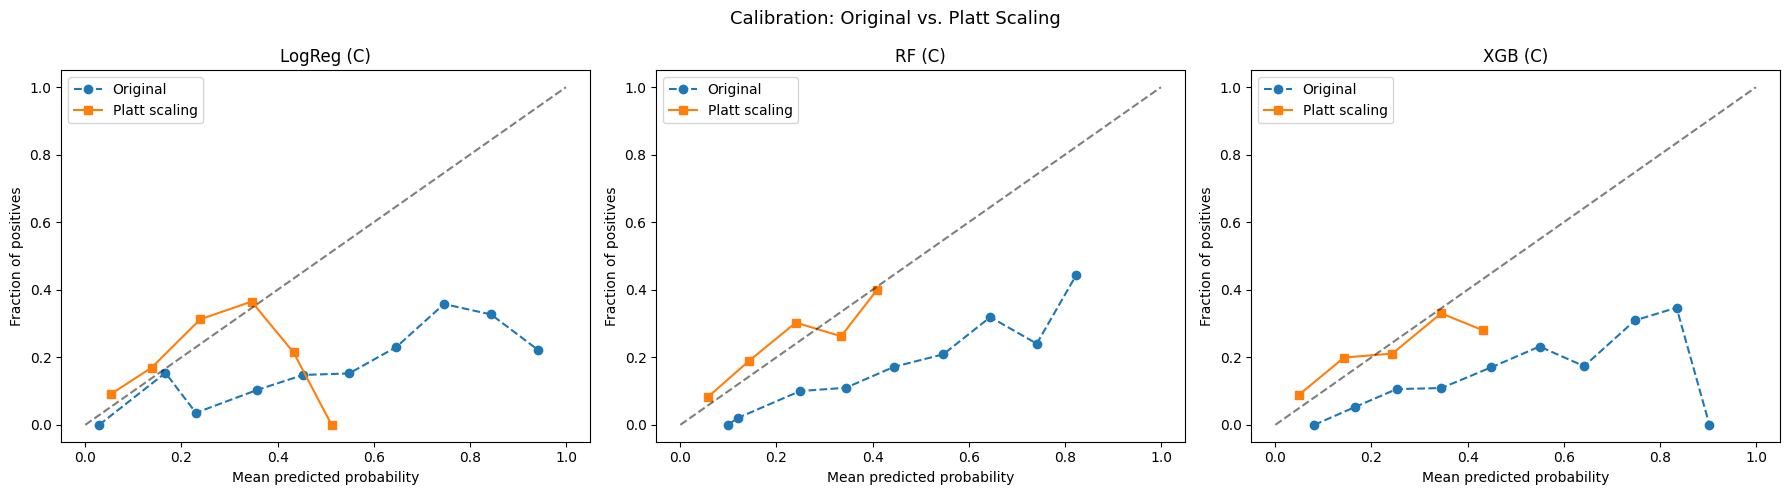

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, key) in zip(axes, [
    ("LogReg (C)", "LogReg_C"),
    ("RF (C)", "RF_C"),
    ("XGB (C)", "XGB_C"),
]):
    # Original
    y_prob_orig = stored[key]["model"].predict_proba(
        stored[key]["X_test"])[:, 1]
    frac, mean = calibration_curve(y_test, y_prob_orig, n_bins=10)
    ax.plot(mean, frac, "o--", label="Original")

    # Platt scaling
    y_prob_cal = calibrated_models[f"{key}_platt"]["y_prob"]
    frac, mean = calibration_curve(y_test, y_prob_cal, n_bins=10)
    ax.plot(mean, frac, "s-", label="Platt scaling")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title(label)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()

plt.suptitle("Calibration: Original vs. Platt Scaling", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
comparison = []
for label, key in [("LogReg_C", "LogReg_C"), ("RF_C", "RF_C"), ("XGB_C", "XGB_C")]:
    y_orig = stored[key]["model"].predict_proba(stored[key]["X_test"])[:, 1]
    y_cal = calibrated_models[f"{key}_platt"]["y_prob"]

    comparison.append({
        "Model": label,
        "Brier (original)": round(brier_score_loss(y_test, y_orig), 4),
        "Brier (Platt)": round(brier_score_loss(y_test, y_cal), 4),
        "AUC (original)": round(roc_auc_score(y_test, y_orig), 3),
        "AUC (Platt)": round(roc_auc_score(y_test, y_cal), 3),
    })

pd.DataFrame(comparison)

,Model,Brier (original),Brier (Platt),AUC (original),AUC (Platt)
0,LogReg_C,0.2299,0.1204,0.681,0.681
1,RF_C,0.1847,0.1192,0.699,0.699
2,XGB_C,0.2015,0.1200,0.692,0.692


All three models are badly under-calibrated (predicting probabilities far too high), but Platt scaling fixes it. Brier scores drop ~40% (e.g. RF from 0.185 to 0.119) while AUC stays identical, so always apply post-hoc calibration before deployment.

## Regional/Income-group Fairness

In [28]:
print(test_df["country"].nunique(), "countries in test set")
print(test_df["country"].sample(20).tolist())

243 countries in test set
['Chile', 'Greece', 'Azerbaijan, Republic of', 'China', 'New Zealand', 'Aruba, Kingdom of the Netherlands', 'Brunei', 'Türkiye, Republic of', 'Cameroon', 'St. Kitts and Nevis', 'Libya', 'Kenya', 'Sint Maarten (Dutch part)', 'Netherlands', 'Namibia', 'Taiwan Province of China', 'United Arab Emirates', 'Albania', 'Bermuda', 'Portugal']


In [29]:
import json

# First let's just see what we're working with — dump all country names
print(sorted(test_df["country"].unique()))

['Afghanistan', 'Africa Western and Central', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Andorra, Principality of', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Armenia, Republic of', 'Aruba', 'Aruba, Kingdom of the Netherlands', 'Australia', 'Austria', 'Azerbaijan', 'Azerbaijan, Republic of', 'Bahamas', 'Bahrain', 'Bahrain, Kingdom of', 'Bangladesh', 'Barbados', 'Belarus', 'Belarus, Republic of', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Caribbean small states', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Croatia, Republic of', 'Cuba', 'Curacao', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Early-demographic dividend', 'Ecuador', 'Eg

In [30]:
# filter out aggregate/regional entities that aren't real countries
aggregates = [
    "Africa Western and Central", "Caribbean small states", "Early-demographic dividend",
    "Heavily indebted poor countries (HIPC)", "Late-demographic dividend",
    "Least developed countries: UN classification", "North America", "OECD members",
    "Pacific island small states", "Post-demographic dividend", "Pre-demographic dividend",
]

high_income = {
    "Andorra", "Andorra, Principality of", "Antigua and Barbuda", "Aruba",
    "Aruba, Kingdom of the Netherlands", "Australia", "Austria", "Bahamas",
    "Bahrain", "Bahrain, Kingdom of", "Barbados", "Belgium", "Bermuda",
    "Brunei", "Canada", "Cayman Islands", "Chile", "Croatia", "Croatia, Republic of",
    "Curacao", "Cyprus", "Czech Republic", "Denmark", "Estonia", "Estonia, Republic of",
    "Faroe Islands", "Finland", "France", "French Polynesia", "Germany", "Greece",
    "Greenland", "Guam", "Hong Kong SAR", "Hungary", "Iceland", "Ireland", "Israel",
    "Italy", "Japan", "Korea, Rep.", "Kuwait", "Latvia", "Latvia, Republic of",
    "Liechtenstein, Principality of", "Lithuania", "Lithuania, Republic of",
    "Luxembourg", "Macao SAR", "Malta", "Mauritius", "Nauru", "Netherlands",
    "Netherlands, The", "New Caledonia", "New Zealand", "Northern Mariana Islands",
    "Norway", "Oman", "Palau", "Panama", "Poland", "Poland, Republic of", "Portugal",
    "Puerto Rico", "Puerto Rico (US)", "Qatar", "Romania", "San Marino",
    "San Marino, Republic of", "Saudi Arabia", "Seychelles", "Singapore",
    "Sint Maarten (Dutch part)", "Slovakia", "Slovenia", "Slovenia, Republic of",
    "Spain", "St. Kitts and Nevis", "Sweden", "Switzerland", "Trinidad and Tobago",
    "United Arab Emirates", "United Kingdom", "United States", "Uruguay",
    "Virgin Islands (U.S.)", "Guyana",
}

upper_middle = {
    "Albania", "Algeria", "American Samoa", "Argentina", "Armenia",
    "Armenia, Republic of", "Azerbaijan", "Azerbaijan, Republic of", "Belarus",
    "Belarus, Republic of", "Belize", "Bosnia and Herzegovina", "Botswana", "Brazil",
    "Bulgaria", "China", "Colombia", "Costa Rica", "Cuba", "Dominica",
    "Dominican Republic", "Ecuador", "Equatorial Guinea", "Fiji", "Fiji, Republic of",
    "Gabon", "Georgia", "Grenada", "Guatemala", "Indonesia", "Iran", "Iraq",
    "Jamaica", "Jordan", "Kazakhstan", "Kazakhstan, Republic of", "Kosovo",
    "Kosovo, Republic of", "Libya", "Malaysia", "Maldives", "Marshall Islands",
    "Mexico", "Moldova", "Moldova, Republic of", "Mongolia", "Montenegro",
    "North Macedonia", "North Macedonia, Republic of", "Paraguay", "Peru",
    "Philippines", "Russia", "Samoa", "Serbia", "Serbia, Republic of",
    "South Africa", "St. Lucia", "St. Vincent and the Grenadines", "Suriname",
    "Thailand", "Tonga", "Turkiye", "Turkmenistan", "Türkiye, Republic of",
    "Venezuela", "West Bank and Gaza",
}

lower_middle = {
    "Angola", "Bangladesh", "Benin", "Bhutan", "Bolivia", "Cabo Verde", "Cambodia",
    "Cameroon", "Comoros", "Congo, Rep.", "Cote d'Ivoire", "Djibouti", "Egypt",
    "El Salvador", "Eswatini", "Ghana", "Guinea-Bissau", "Haiti", "Honduras",
    "India", "Kenya", "Kiribati", "Kyrgyzstan", "Laos", "Lebanon", "Lesotho",
    "Mauritania", "Micronesia, Fed. Sts.", "Morocco", "Myanmar", "Nepal",
    "Nicaragua", "Nigeria", "Pakistan", "Papua New Guinea", "Sao Tome and Principe",
    "Senegal", "Solomon Islands", "Sri Lanka", "Sudan", "Syria Arab Republic",
    "Tajikistan", "Tanzania", "Timor-Leste", "Togo", "Tunisia", "Ukraine",
    "Uzbekistan", "Uzbekistan, Republic of", "Vanuatu", "Viet Nam", "Vietnam",
    "Zimbabwe", "Taiwan Province of China",
}

low_income = {
    "Afghanistan", "Burkina Faso", "Burundi", "Central African Republic", "Chad",
    "Congo, Dem. Rep.", "Ethiopia", "Gambia", "Guinea", "Liberia", "Madagascar",
    "Malawi", "Mali", "Mozambique", "Niger", "Rwanda", "Sierra Leone",
    "Somalia, Fed. Rep.", "South Sudan", "Syrian Arab Republic", "Tuvalu", "Uganda",
    "Zambia",
}


def get_income_group(country):
    if country in aggregates:
        return "Aggregate"
    elif country in high_income:
        return "High income"
    elif country in upper_middle:
        return "Upper middle income"
    elif country in lower_middle:
        return "Lower middle income"
    elif country in low_income:
        return "Low income"
    else:
        return "Unclassified"


test_df = test_df.copy()
test_df["income_group"] = test_df["country"].apply(get_income_group)
print(test_df["income_group"].value_counts())
print(
    f"\nUnclassified: {test_df[test_df['income_group'] == 'Unclassified']['country'].unique()}")

income_group
High income            840
Upper middle income    597
Lower middle income    403
Low income             134
Aggregate               66
Unclassified             6
Name: count, dtype: int64

Unclassified: <ArrowStringArray>
['Namibia']
Length: 1, dtype: str


In [31]:
key = "XGB_B"
y_prob = stored[key]["model"].predict_proba(stored[key]["X_test"])[:, 1]

results = []
for group in ["High income", "Upper middle income", "Lower middle income", "Low income"]:
    mask = test_df["income_group"].values == group
    n = mask.sum()
    n_pos = int(y_test.values[mask].sum())

    if n_pos < 2 or n_pos == n:
        print(f"{group}: n={n}, positives={n_pos} — too few to compute AUC")
        continue

    auc = roc_auc_score(y_test.values[mask], y_prob[mask])
    results.append({"Income Group": group, "AUC": round(auc, 3),
                    "n": n, "Recessions": n_pos, "Rate": f"{n_pos/n:.1%}"})
    print(f"{group}: AUC={auc:.3f} (n={n}, recessions={n_pos}, rate={n_pos/n:.1%})")

pd.DataFrame(results)

High income: AUC=0.688 (n=840, recessions=115, rate=13.7%)
Upper middle income: AUC=0.724 (n=597, recessions=87, rate=14.6%)
Lower middle income: AUC=0.741 (n=403, recessions=67, rate=16.6%)
Low income: AUC=0.620 (n=134, recessions=18, rate=13.4%)


,Income Group,AUC,n,Recessions,Rate
0,High income,0.688,840,115,13.7%
1,Upper middle income,0.724,597,87,14.6%
2,Lower middle income,0.741,403,67,16.6%
3,Low income,0.620,134,18,13.4%


Model performs best for middle-income economies (AUC 0.72–0.74), weaker for high-income (0.69) due to missing financial-market features, and weakest for low-income (0.62) due to limited data — don't deploy uniformly across income groups.

## Error cost/Threshold Analysis

 Threshold  TP   FP  FN   TN  Recall  Precision  Cost (5:1)  Cost (10:1)
      0.05 299 1747   0    0   1.000      0.146        1747         1747
      0.10 299 1747   0    0   1.000      0.146        1747         1747
      0.15 299 1579   0  168   1.000      0.159        1579         1579
      0.20 299 1447   0  300   1.000      0.171        1447         1447
      0.25 282 1295  17  452   0.943      0.179        1380         1465
      0.30 256 1088  43  659   0.856      0.190        1303         1518
      0.35 233  924  66  823   0.779      0.201        1254         1584
      0.40 212  771  87  976   0.709      0.216        1206         1641
      0.45 197  647 102 1100   0.659      0.233        1157         1667
      0.50 176  519 123 1228   0.589      0.253        1134         1749
      0.55 159  442 140 1305   0.532      0.265        1142         1842
      0.60 127  322 172 1425   0.425      0.283        1182         2042
      0.65  92  204 207 1543   0.308      0.311    

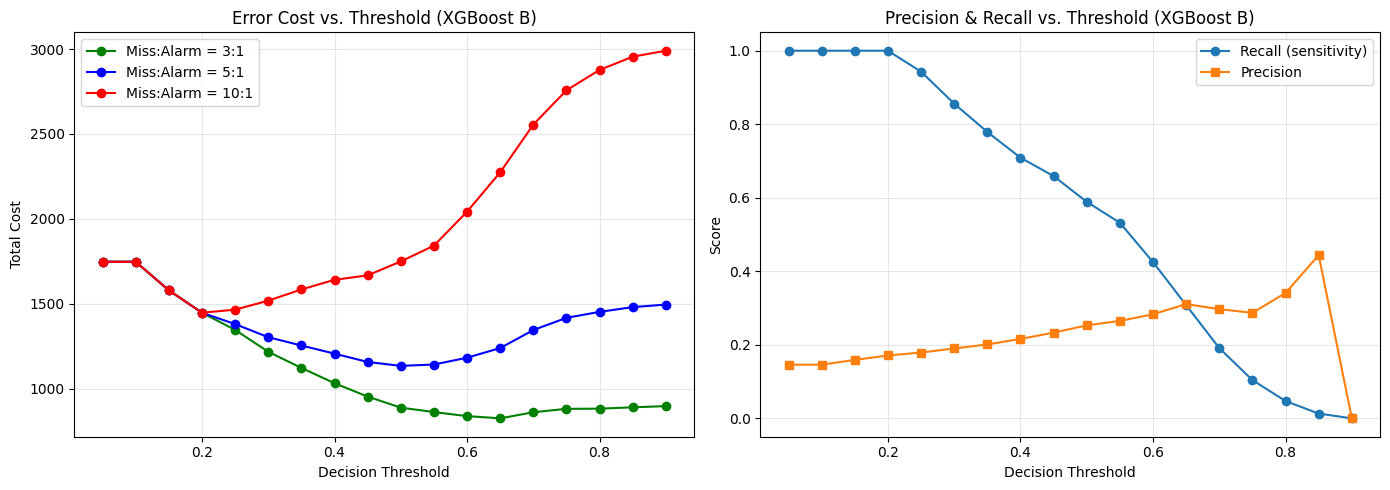

Cost ratio 3:1 -> optimal threshold = 0.65, recall = 0.308, precision = 0.311
Cost ratio 5:1 -> optimal threshold = 0.5, recall = 0.589, precision = 0.253
Cost ratio 10:1 -> optimal threshold = 0.2, recall = 1.0, precision = 0.171


In [32]:
key = "XGB_B"
y_prob = stored[key]["model"].predict_proba(stored[key]["X_test"])[:, 1]

thresholds = np.arange(0.05, 0.95, 0.05)

# metrics at each threshold
rows = []
for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    rows.append({
        "Threshold": round(t, 2),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Recall": round(tp / (tp + fn), 3) if (tp + fn) > 0 else 0,
        "Precision": round(tp / (tp + fp), 3) if (tp + fp) > 0 else 0,
        "Cost (5:1)": 5 * fn + 1 * fp,
        "Cost (10:1)": 10 * fn + 1 * fp,
    })

cost_df = pd.DataFrame(rows)
print(cost_df.to_string(index=False))

# cost curves under different asymmetries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cost curves
for ratio, color in [(3, "green"), (5, "blue"), (10, "red")]:
    costs = [ratio * r["FN"] + r["FP"] for r in rows]
    axes[0].plot(thresholds, costs, marker="o", color=color,
                 label=f"Miss:Alarm = {ratio}:1")

axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("Total Cost")
axes[0].set_title("Error Cost vs. Threshold (XGBoost B)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# right: precision-recall tradeoff by threshold
recalls = [r["Recall"] for r in rows]
precisions = [r["Precision"] for r in rows]
axes[1].plot(thresholds, recalls, "o-", label="Recall (sensitivity)")
axes[1].plot(thresholds, precisions, "s-", label="Precision")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision & Recall vs. Threshold (XGBoost B)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for ratio in [3, 5, 10]:
    costs = [ratio * r["FN"] + r["FP"] for r in rows]
    best_idx = np.argmin(costs)
    best_t = rows[best_idx]["Threshold"]
    print(f"Cost ratio {ratio}:1 -> optimal threshold = {best_t}, "
          f"recall = {rows[best_idx]['Recall']}, precision = {rows[best_idx]['Precision']}")

All models perform similarly (overlapping CIs), calibration is poor but fixable with Platt scaling, the model works best for middle-income economies, and the optimal threshold depends on how much worse a missed recession is vs. a false alarm - policymakers should use ~0.15–0.20, not the default 0.50.